In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Load CSV
df = pd.read_csv("downloads/HistoricalQuotes.csv")

# Clean column names
df.columns = df.columns.str.strip()
df.rename(columns={"Close/Last": "Close"}, inplace=True)

# Clean Close column (remove $ and commas, and convert to float)
df["Close"] = (
    df["Close"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
    .astype(float)
)

# Convert Date to datetime and set as index
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")

# Calculate daily returns
df["Return"] = df["Close"].pct_change()

# Quick check
print(df[["Close", "Return"]].head())


              Close    Return
Date                         
2010-03-01  29.8557       NaN
2010-03-02  29.8357 -0.000670
2010-03-03  29.9043  0.002299
2010-03-04  30.1014  0.006591
2010-03-05  31.2786  0.039108


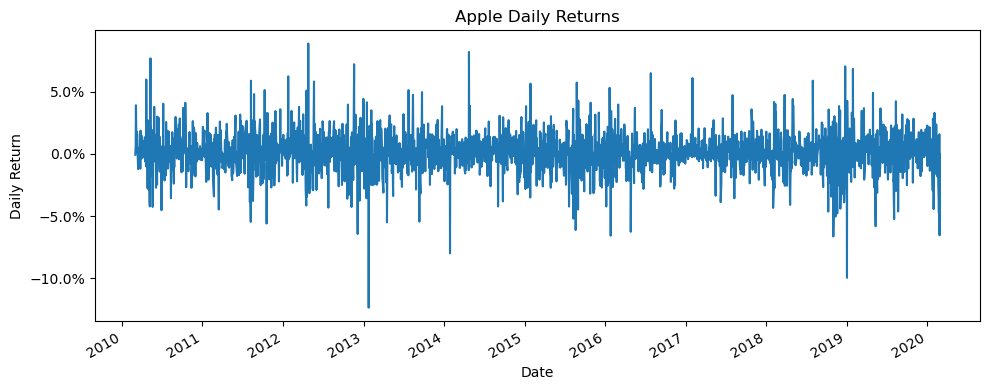

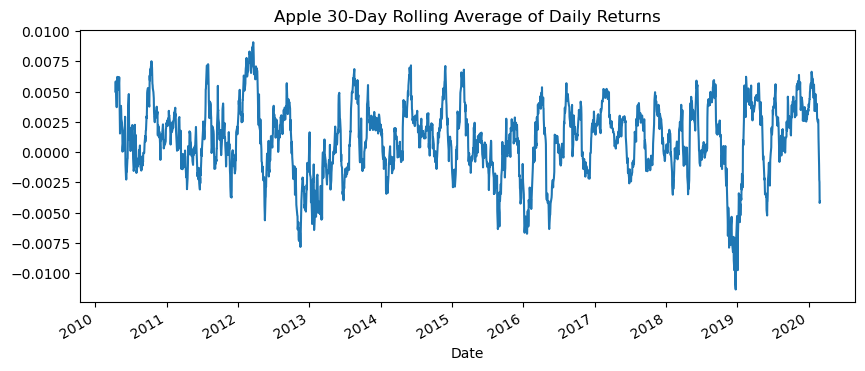

In [5]:
# Plot returns
ax = df["Return"].plot(figsize=(10, 4))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # show as %
plt.title("Apple Daily Returns")
plt.ylabel("Daily Return")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

df["Return"].rolling(30).mean().plot(figsize=(10,4))
plt.title("Apple 30-Day Rolling Average of Daily Returns")
plt.show()

